# 04 - Custom Sequence Model Training (Leakage-Safe)

Trains GRU next-token models on file-level split windows from notebook 02.


In [ ]:
# Optional for Colab
!pip install -q torch pandas numpy matplotlib mido


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

def to_loader(X, y, batch_size=64, shuffle=True):
    """DataLoader from split window lists (train_X / train_y from notebook 02 cache)."""
    X_t = torch.tensor(np.asarray(X), dtype=torch.long)
    y_t = torch.tensor(np.asarray(y), dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


class GRUNextToken(nn.Module):
    def __init__(self, vocab_size, emb=128, hid=192, layers=1, drop=0.2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb)
        self.rnn = nn.GRU(emb, hid, num_layers=layers, batch_first=True)
        self.drop = nn.Dropout(drop)
        self.fc = nn.Linear(hid, vocab_size)

    def forward(self, x):
        o, _ = self.rnn(self.emb(x))
        return self.fc(self.drop(o[:, -1, :]))


PROJECT_OUTPUT_DIR = Path('/content/notebook4_outputs')
CACHE_DIR = PROJECT_OUTPUT_DIR / 'cache'
TABLE_DIR = PROJECT_OUTPUT_DIR / 'tables'
FIG_DIR = PROJECT_OUTPUT_DIR / 'figures'

with open('/content/sequence_cache.json', 'r') as f:
    cache = json.load(f)

V = len(cache['vocab'])
sw = cache['split_windows']
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, 'Vocab:', V)


Device: cuda Vocab: 5326


In [ ]:
def train_setting(name, split_key, epochs=10, batch_size=64, lr=1e-3, log_every=1):
    trX, trY = sw[split_key]['train_X'], sw[split_key]['train_y']
    vaX, vaY = sw[split_key]['val_X'], sw[split_key]['val_y']
    teX, teY = sw[split_key]['test_X'], sw[split_key]['test_y']

    tr = to_loader(trX, trY, batch_size=batch_size, shuffle=True)
    va = to_loader(vaX, vaY, batch_size=batch_size, shuffle=False)
    te = to_loader(teX, teY, batch_size=batch_size, shuffle=False)

    model = GRUNextToken(V, emb=128, hid=192, layers=1, drop=0.2).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    hist = []
    print(f"\n=== Training {name} ===")
    print(f"train windows={len(trX)}, val windows={len(vaX)}, test windows={len(teX)}")

    for ep in range(1, epochs + 1):
        model.train()
        tr_losses = []
        tr_correct = 0
        tr_total = 0

        for xb, yb in tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tr_losses.append(loss.item())
            preds = logits.argmax(dim=1)
            tr_correct += (preds == yb).sum().item()
            tr_total += yb.size(0)

        train_loss = float(np.mean(tr_losses))
        train_acc = float(tr_correct / max(tr_total, 1))

        model.eval()
        va_losses = []
        va_correct = 0
        va_total = 0
        with torch.no_grad():
            for xb, yb in va:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                va_losses.append(crit(logits, yb).item())
                preds = logits.argmax(dim=1)
                va_correct += (preds == yb).sum().item()
                va_total += yb.size(0)

        val_loss = float(np.mean(va_losses))
        val_acc = float(va_correct / max(va_total, 1))

        hist.append({
            'setting': name,
            'epoch': ep,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        })

        if ep % log_every == 0:
            print(
                f"[{name}] epoch {ep:02d}/{epochs} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
            )

    # Test metrics
    model.eval()
    all_probs = []
    all_y = []
    with torch.no_grad():
        for xb, yb in te:
            xb = xb.to(device)
            probs = torch.softmax(model(xb), dim=-1).cpu().numpy()
            all_probs.append(probs)
            all_y.extend(yb.numpy().tolist())

    probs = np.vstack(all_probs)
    preds = probs.argmax(axis=1)
    acc = float(np.mean(np.array(all_y) == preds))
    ptrue = np.array([max(probs[i, t], 1e-12) for i, t in enumerate(all_y)])
    ce = float(-np.mean(np.log(ptrue)))
    ppl = float(np.exp(ce))
    k = min(5, probs.shape[1])
    topk = np.mean([all_y[i] in np.argpartition(probs[i], -k)[-k:] for i in range(len(all_y))])

    print(f"[{name}] FINAL | test_acc={acc:.4f} test_ce={ce:.4f} test_ppl={ppl:.4f} test_top5={topk:.4f}")

    return model, pd.DataFrame(hist), {
        'setting': name,
        'model': 'gru_custom',
        'accuracy': acc,
        'cross_entropy': ce,
        'perplexity': ppl,
        'top5': float(topk)
    }

In [ ]:
raw_model, raw_hist, raw_met = train_setting('raw_time', 'raw')
q_model, q_hist, q_met = train_setting('quantized_time', 'quant')

hist_df = pd.concat([raw_hist, q_hist], ignore_index=True)
metrics_df = pd.DataFrame([raw_met, q_met])
display(metrics_df)



=== Training raw_time ===
train windows=308189, val windows=36253, test windows=44737
[raw_time] epoch 01/10 | train_loss=4.4681 train_acc=0.0979 | val_loss=4.0348 val_acc=0.1421
[raw_time] epoch 02/10 | train_loss=3.9181 train_acc=0.1539 | val_loss=3.8637 val_acc=0.1644
[raw_time] epoch 03/10 | train_loss=3.7929 train_acc=0.1675 | val_loss=3.7867 val_acc=0.1720
[raw_time] epoch 04/10 | train_loss=3.7353 train_acc=0.1748 | val_loss=3.7471 val_acc=0.1782
[raw_time] epoch 05/10 | train_loss=3.7013 train_acc=0.1798 | val_loss=3.7347 val_acc=0.1738
[raw_time] epoch 06/10 | train_loss=3.6775 train_acc=0.1817 | val_loss=3.7145 val_acc=0.1807
[raw_time] epoch 07/10 | train_loss=3.6594 train_acc=0.1846 | val_loss=3.7075 val_acc=0.1807
[raw_time] epoch 08/10 | train_loss=3.6445 train_acc=0.1855 | val_loss=3.6879 val_acc=0.1825
[raw_time] epoch 09/10 | train_loss=3.6298 train_acc=0.1873 | val_loss=3.6880 val_acc=0.1812
[raw_time] epoch 10/10 | train_loss=3.6212 train_acc=0.1879 | val_loss=3.675

,setting,model,accuracy,cross_entropy,perplexity,top5
0,raw_time,gru_custom,0.187228,3.617372,37.239575,0.432841
1,quantized_time,gru_custom,0.280280,2.743658,15.543741,0.638600


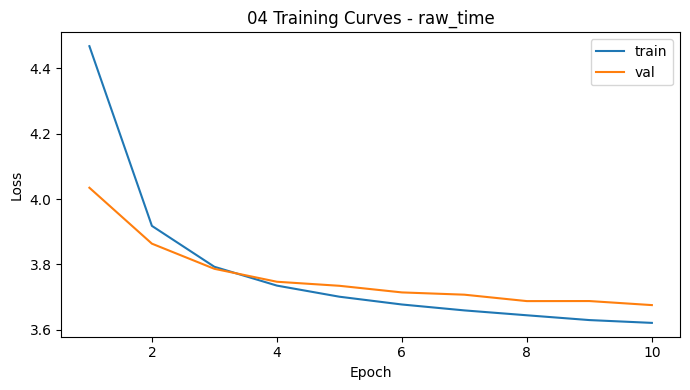

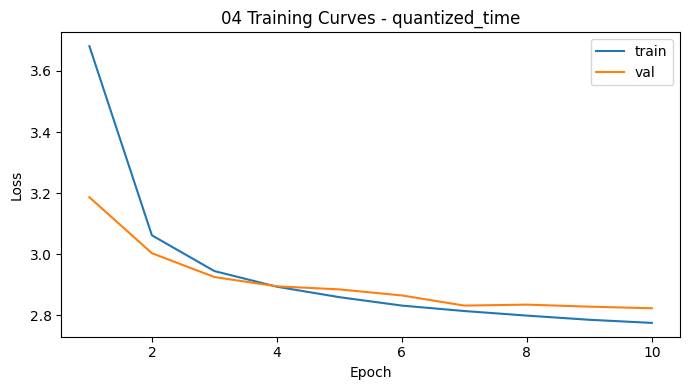

In [ ]:
for s in hist_df['setting'].unique():
    sub = hist_df[hist_df['setting'] == s]
    plt.figure(figsize=(7,4))
    plt.plot(sub['epoch'], sub['train_loss'], label='train')
    plt.plot(sub['epoch'], sub['val_loss'], label='val')
    plt.title(f'04 Training Curves - {s}')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout()
    plt.savefig(FIG_DIR / f'04_training_curve_{s}.png', dpi=160)
    plt.show()


In [ ]:
id2tok = {int(k): v for k, v in cache['id2tok'].items()} if isinstance(next(iter(cache['id2tok'].keys())), str) else cache['id2tok']


def sample_continuation(model, prefix_ids, steps=80, temperature=1.0):
    model.eval()
    out = list(prefix_ids)
    ctx_len = len(prefix_ids)
    for _ in range(steps):
        x = torch.tensor([out[-ctx_len:]], dtype=torch.long, device=device)
        with torch.no_grad():
            logits = model(x)[0] / max(temperature, 1e-6)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        nxt = int(np.random.choice(len(probs), p=probs / probs.sum()))
        out.append(nxt)
    return out

raw_prefix = sw['raw']['test_X'][0]
q_prefix = sw['quant']['test_X'][0]
raw_gen = sample_continuation(raw_model, raw_prefix, steps=120)
q_gen = sample_continuation(q_model, q_prefix, steps=120)

# Fixed newline join bug.
with open(CACHE_DIR / '04_generated_tokens_raw.txt', 'w') as f:
    f.write('\n'.join([id2tok.get(i, str(i)) for i in raw_gen]))
with open(CACHE_DIR / '04_generated_tokens_quantized.txt', 'w') as f:
    f.write('\n'.join([id2tok.get(i, str(i)) for i in q_gen]))


In [ ]:
hist_df.to_csv(TABLE_DIR / '04_training_history.csv', index=False)
metrics_df.to_csv(TABLE_DIR / '04_training_metrics.csv', index=False)
torch.save(raw_model.state_dict(), CACHE_DIR / '04_gru_raw.pt')
torch.save(q_model.state_dict(), CACHE_DIR / '04_gru_quantized.pt')
print('Saved notebook 04 outputs.')


Saved notebook 04 outputs.


In [ ]:
from datetime import datetime
import json
import pandas as pd

# -----------------------------
# Editable experiment metadata
# -----------------------------
EXPERIMENT_NAME = 'gru_baseline'
EXPERIMENT_TAG = 'v1'
ARCH_NOTES = 'GRU next-token model, leakage-safe split windows'

# Keep these aligned with train_setting defaults unless you changed them.
TRAIN_HPARAMS = {
    "model_class": "GRUNextToken",
    "vocab_size": V,
    "embedding_dim": 128,
    "hidden_dim": 192,
    "num_layers": 1,
    "dropout": 0.2,
    "optimizer": "Adam",
    "learning_rate": 3e-3,
    "weight_decay": 1e-4,
    "loss_fn": "CrossEntropyLoss",
    "grad_clip_max_norm": 1.0,
    "epochs": 20,
    "batch_size": 64,
    "log_every": 1,
    "temperature_sampling": 1.0,
    "seed": 42,
    "split_strategy": "file_level_from_sequence_cache_split_windows",
    "train_windows_raw": 308189,
    "val_windows_raw": 36253,
    "test_windows_raw": 44737,
    "train_windows_quantized": 284941,
    "val_windows_quantized": 33517,
    "test_windows_quantized": 41223
}

run_ts = datetime.utcnow().strftime('%Y%m%d_%H%M%S')
run_id = f"{run_ts}__{EXPERIMENT_NAME}__{EXPERIMENT_TAG}"

print('Prepared run_id:', run_id)
print('Model class:', raw_model.__class__.__name__)
print('Train hparams:', TRAIN_HPARAMS)


Prepared run_id: 20260428_012139__gru_baseline__v1
Model class: GRUNextToken
Train hparams: {'model_class': 'GRUNextToken', 'vocab_size': 5326, 'embedding_dim': 128, 'hidden_dim': 192, 'num_layers': 1, 'dropout': 0.2, 'optimizer': 'Adam', 'learning_rate': 0.003, 'weight_decay': 0.0001, 'loss_fn': 'CrossEntropyLoss', 'grad_clip_max_norm': 1.0, 'epochs': 20, 'batch_size': 64, 'log_every': 1, 'temperature_sampling': 1.0, 'seed': 42, 'split_strategy': 'file_level_from_sequence_cache_split_windows', 'train_windows_raw': 308189, 'val_windows_raw': 36253, 'test_windows_raw': 44737, 'train_windows_quantized': 284941, 'val_windows_quantized': 33517, 'test_windows_quantized': 41223}


/tmp/ipykernel_11335/2933975930.py:39: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_ts = datetime.utcnow().strftime('%Y%m%d_%H%M%S')


In [ ]:
# Create per-setting experiment log rows.
# This cell expects raw_met, q_met, hist_df, metrics_df, raw_model, q_model from earlier cells.

if 'metrics_df' not in globals() or 'hist_df' not in globals():
    raise RuntimeError('Run training cells first so metrics_df and hist_df exist.')

n_train_raw = len(sw['raw']['train_X'])
n_val_raw = len(sw['raw']['val_X'])
n_test_raw = len(sw['raw']['test_X'])
n_train_q = len(sw['quant']['train_X'])
n_val_q = len(sw['quant']['val_X'])
n_test_q = len(sw['quant']['test_X'])

run_rows = []
for setting in ['raw_time', 'quantized_time']:
    mrow = metrics_df[metrics_df['setting'] == setting].iloc[0].to_dict()
    hsub = hist_df[hist_df['setting'] == setting]
    final_train_loss = float(hsub['train_loss'].iloc[-1])
    final_val_loss = float(hsub['val_loss'].iloc[-1])

    if setting == 'raw_time':
        n_train, n_val, n_test = n_train_raw, n_val_raw, n_test_raw
        checkpoint_name = f"04_gru_raw__{run_id}.pt"
    else:
        n_train, n_val, n_test = n_train_q, n_val_q, n_test_q
        checkpoint_name = f"04_gru_quantized__{run_id}.pt"

    run_rows.append({
        'run_id': run_id,
        'timestamp_utc': run_ts,
        'experiment_name': EXPERIMENT_NAME,
        'experiment_tag': EXPERIMENT_TAG,
        'setting': setting,
        'model_class': raw_model.__class__.__name__,
        'architecture_notes': ARCH_NOTES,
        'n_train_windows': n_train,
        'n_val_windows': n_val,
        'n_test_windows': n_test,
        'final_train_loss': final_train_loss,
        'final_val_loss': final_val_loss,
        'accuracy': float(mrow['accuracy']),
        'cross_entropy': float(mrow['cross_entropy']),
        'perplexity': float(mrow['perplexity']),
        'top5': float(mrow['top5']),
        'checkpoint_file': checkpoint_name,
        'hparams_json': json.dumps(TRAIN_HPARAMS, sort_keys=True),
    })

run_log_df = pd.DataFrame(run_rows)
display(run_log_df)


,run_id,timestamp_utc,experiment_name,experiment_tag,setting,model_class,architecture_notes,n_train_windows,n_val_windows,n_test_windows,final_train_loss,final_val_loss,accuracy,cross_entropy,perplexity,top5,checkpoint_file,hparams_json
0,20260428_012139__gru_baseline__v1,20260428_012139,gru_baseline,v1,raw_time,GRUNextToken,"GRU next-token model, leakage-safe split windows",308189,36253,44737,3.621225,3.675659,0.187228,3.617372,37.239575,0.432841,04_gru_raw__20260428_012139__gru_baseline__v1.pt,"{""batch_size"": 64, ""dropout"": 0.2, ""embedding_..."
1,20260428_012139__gru_baseline__v1,20260428_012139,gru_baseline,v1,quantized_time,GRUNextToken,"GRU next-token model, leakage-safe split windows",284941,33517,41223,2.774678,2.822602,0.280280,2.743658,15.543741,0.638600,04_gru_quantized__20260428_012139__gru_baselin...,"{""batch_size"": 64, ""dropout"": 0.2, ""embedding_..."


In [ ]:
# Append experiment rows to cumulative log CSV and save full run metadata JSON.
exp_log_csv = TABLE_DIR / '04_experiment_log.csv'
exp_meta_json = CACHE_DIR / f'04_experiment_meta__{run_id}.json'

if exp_log_csv.exists():
    old = pd.read_csv(exp_log_csv)
    merged = pd.concat([old, run_log_df], ignore_index=True)
else:
    merged = run_log_df.copy()

merged.to_csv(exp_log_csv, index=False)

meta_payload = {
    'run_id': run_id,
    'timestamp_utc': run_ts,
    'experiment_name': EXPERIMENT_NAME,
    'experiment_tag': EXPERIMENT_TAG,
    'architecture_notes': ARCH_NOTES,
    'hparams': TRAIN_HPARAMS,
    'metrics': run_log_df.to_dict(orient='records'),
}
with open(exp_meta_json, 'w') as f:
    json.dump(meta_payload, f, indent=2)

print('Updated cumulative experiment log:', exp_log_csv)
print('Saved run metadata json:', exp_meta_json)


Updated cumulative experiment log: /content/notebook4_outputs/tables/04_experiment_log.csv
Saved run metadata json: /content/notebook4_outputs/cache/04_experiment_meta__20260428_012139__gru_baseline__v1.json


In [ ]:
# Save versioned checkpoints for this run_id (in addition to default checkpoint files from cell 7).
raw_ckpt = CACHE_DIR / f'04_gru_raw__{run_id}.pt'
q_ckpt = CACHE_DIR / f'04_gru_quantized__{run_id}.pt'

torch.save(raw_model.state_dict(), raw_ckpt)
torch.save(q_model.state_dict(), q_ckpt)

print('Saved versioned raw checkpoint:', raw_ckpt)
print('Saved versioned quantized checkpoint:', q_ckpt)


Saved versioned raw checkpoint: /content/notebook4_outputs/cache/04_gru_raw__20260428_012139__gru_baseline__v1.pt
Saved versioned quantized checkpoint: /content/notebook4_outputs/cache/04_gru_quantized__20260428_012139__gru_baseline__v1.pt



# TESTING TRANSFORMER ARCHITECTURE

In [ ]:
# -----------------------------
# Optional Transformer run
# -----------------------------
# Tune these knobs as needed for Colab runtime.
TRANSFORMER_SETTING = 'quantized_time'  # choose 'quantized_time' or 'raw_time'
TF_EPOCHS = 10
TF_BATCH_SIZE = 64
TF_LR = 1e-3
TF_EMB = 192
TF_HEADS = 6
TF_LAYERS = 3
TF_FF_MULT = 4
TF_DROPOUT = 0.2
TF_MAX_LEN = max(len(x) for x in sw['quant']['train_X']) if TRANSFORMER_SETTING == 'quantized_time' else max(len(x) for x in sw['raw']['train_X'])

import math


def make_split_loaders(split_key, batch_size=64):
    trX, trY = sw[split_key]['train_X'], sw[split_key]['train_y']
    vaX, vaY = sw[split_key]['val_X'], sw[split_key]['val_y']
    teX, teY = sw[split_key]['test_X'], sw[split_key]['test_y']
    return (
        to_loader(trX, trY, batch_size=batch_size, shuffle=True),
        to_loader(vaX, vaY, batch_size=batch_size, shuffle=False),
        to_loader(teX, teY, batch_size=batch_size, shuffle=False),
        (trX, trY, vaX, vaY, teX, teY),
    )


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x: [B, T, D]
        return x + self.pe[:, :x.size(1), :]


class TransformerNextToken(nn.Module):
    def __init__(self, vocab_size, emb_dim=192, nhead=6, num_layers=3, ff_mult=4, dropout=0.2, max_len=512):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.pos = PositionalEncoding(emb_dim, max_len=max_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=nhead,
            dim_feedforward=emb_dim * ff_mult,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):
        # x: [B, T]
        h = self.emb(x)
        h = self.pos(h)
        h = self.enc(h)
        h = self.drop(h[:, -1, :])
        return self.fc(h)


def train_transformer_setting(name, split_key):
    tr, va, te, split_data = make_split_loaders(split_key, batch_size=TF_BATCH_SIZE)
    trX, trY, vaX, vaY, teX, teY = split_data

    model = TransformerNextToken(
        vocab_size=V,
        emb_dim=TF_EMB,
        nhead=TF_HEADS,
        num_layers=TF_LAYERS,
        ff_mult=TF_FF_MULT,
        dropout=TF_DROPOUT,
        max_len=max(TF_MAX_LEN, 256),
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=TF_LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, TF_EPOCHS))
    crit = nn.CrossEntropyLoss()

    hist = []
    print(f"=== Transformer Training ({name}) ===")
    print(f"train windows={len(trX)}, val windows={len(vaX)}, test windows={len(teX)}")

    for ep in range(1, TF_EPOCHS + 1):
        model.train(); tr_losses=[]; tr_correct=0; tr_total=0
        for xb, yb in tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tr_losses.append(loss.item())
            preds = logits.argmax(dim=1)
            tr_correct += (preds == yb).sum().item()
            tr_total += yb.size(0)

        sched.step()

        model.eval(); va_losses=[]; va_correct=0; va_total=0
        with torch.no_grad():
            for xb, yb in va:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                va_losses.append(crit(logits, yb).item())
                preds = logits.argmax(dim=1)
                va_correct += (preds == yb).sum().item()
                va_total += yb.size(0)

        train_loss = float(np.mean(tr_losses))
        val_loss = float(np.mean(va_losses))
        train_acc = float(tr_correct / max(tr_total, 1))
        val_acc = float(va_correct / max(va_total, 1))

        hist.append({
            'setting': name,
            'model': 'transformer_custom',
            'epoch': ep,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'lr': float(opt.param_groups[0]['lr']),
        })

        print(f"[{name}/transformer] epoch {ep:02d}/{TF_EPOCHS} | "f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    # Test metrics
    model.eval(); all_probs=[]; all_y=[]
    with torch.no_grad():
        for xb, yb in te:
            xb = xb.to(device)
            probs = torch.softmax(model(xb), dim=-1).cpu().numpy()
            all_probs.append(probs)
            all_y.extend(yb.numpy().tolist())

    probs = np.vstack(all_probs)
    preds = probs.argmax(axis=1)
    acc = float(np.mean(np.array(all_y) == preds))
    ptrue = np.array([max(probs[i, t], 1e-12) for i, t in enumerate(all_y)])
    ce = float(-np.mean(np.log(ptrue)))
    ppl = float(np.exp(ce))
    k = min(5, probs.shape[1])
    topk = float(np.mean([all_y[i] in np.argpartition(probs[i], -k)[-k:] for i in range(len(all_y))]))

    final_metrics = {
        'setting': name,
        'model': 'transformer_custom',
        'accuracy': acc,
        'cross_entropy': ce,
        'perplexity': ppl,
        'top5': topk,
        'emb_dim': TF_EMB,
        'n_heads': TF_HEADS,
        'n_layers': TF_LAYERS,
        'epochs': TF_EPOCHS,
        'batch_size': TF_BATCH_SIZE,
        'lr': TF_LR,
        'dropout': TF_DROPOUT,
    }

    print(f"[{name}/transformer] FINAL | test_acc={acc:.4f} test_ce={ce:.4f} test_ppl={ppl:.4f} test_top5={topk:.4f}")
    return model, pd.DataFrame(hist), pd.DataFrame([final_metrics])


split_key = 'quant' if TRANSFORMER_SETTING == 'quantized_time' else 'raw'
tf_model, tf_hist_df, tf_metrics_df = train_transformer_setting(TRANSFORMER_SETTING, split_key)
display(tf_metrics_df)

# Save standalone outputs (non-destructive; does not overwrite GRU artifacts).
tf_hist_path = TABLE_DIR / f'04_training_history_transformer_{TRANSFORMER_SETTING}.csv'
tf_metrics_path = TABLE_DIR / f'04_training_metrics_transformer_{TRANSFORMER_SETTING}.csv'
tf_ckpt_path = CACHE_DIR / f'04_transformer_{TRANSFORMER_SETTING}.pt'

tf_hist_df.to_csv(tf_hist_path, index=False)
tf_metrics_df.to_csv(tf_metrics_path, index=False)
torch.save(tf_model.state_dict(), tf_ckpt_path)

print('Saved transformer history:', tf_hist_path)
print('Saved transformer metrics:', tf_metrics_path)
print('Saved transformer checkpoint:', tf_ckpt_path)


/tmp/ipykernel_11335/3571035355.py:60: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


=== Transformer Training (quantized_time) ===
train windows=284941, val windows=33517, test windows=41223
[quantized_time/transformer] epoch 01/10 | train_loss=3.5354 train_acc=0.2046 | val_loss=3.2299 val_acc=0.2347
[quantized_time/transformer] epoch 02/10 | train_loss=3.1927 train_acc=0.2390 | val_loss=3.1001 val_acc=0.2457
[quantized_time/transformer] epoch 03/10 | train_loss=3.0758 train_acc=0.2514 | val_loss=3.0523 val_acc=0.2523
[quantized_time/transformer] epoch 04/10 | train_loss=2.9886 train_acc=0.2599 | val_loss=2.9791 val_acc=0.2572
[quantized_time/transformer] epoch 05/10 | train_loss=2.9129 train_acc=0.2685 | val_loss=2.9526 val_acc=0.2598
[quantized_time/transformer] epoch 06/10 | train_loss=2.8387 train_acc=0.2776 | val_loss=2.9105 val_acc=0.2647
[quantized_time/transformer] epoch 07/10 | train_loss=2.7704 train_acc=0.2853 | val_loss=2.8826 val_acc=0.2696
[quantized_time/transformer] epoch 08/10 | train_loss=2.7087 train_acc=0.2935 | val_loss=2.8374 val_acc=0.2725
[quant

,setting,model,accuracy,cross_entropy,perplexity,top5,emb_dim,n_heads,n_layers,epochs,batch_size,lr,dropout
0,quantized_time,transformer_custom,0.285278,2.73885,15.469179,0.64464,192,6,3,10,64,0.001,0.2


Saved transformer history: /content/notebook4_outputs/tables/04_training_history_transformer_quantized_time.csv
Saved transformer metrics: /content/notebook4_outputs/tables/04_training_metrics_transformer_quantized_time.csv
Saved transformer checkpoint: /content/notebook4_outputs/cache/04_transformer_quantized_time.pt


In [ ]:
import shutil
shutil.make_archive('/content/notebook4_outputs', 'zip', '/content/notebook4_outputs')

'/content/notebook4_outputs.zip'